# Perceptron: Classic Update Rule vs. Gradient Descent on Perceptron Loss

This notebook trains two binary linear classifiers on a linearly separable synthetic dataset:

1. **Perceptron Learning Algorithm (PLA)** using the classic update rule:  
   when a sample is misclassified, *add or subtract the input features* from the weights  
   (equivalently, $\,\mathbf{w} \leftarrow \mathbf{w} + y \mathbf{x}\,$ with labels $y \in \{-1, +1\}$).  
   Training repeats until no mistakes occur or a maximum number of epochs is reached.

2. **Batch Gradient Descent on the Perceptron Loss**, minimizing
   $$
   L(\mathbf{w}) = \sum_{i=1}^n \max(0,\ -y_i\, \mathbf{w}^{\top} \mathbf{x}_i).
   $$
   The subgradient for each misclassified sample is $-y_i \mathbf{x}_i$.  
   A batch gradient step updates:
   $$
   \mathbf{w}
   \leftarrow
   \mathbf{w} - \alpha \nabla L
   =
   \mathbf{w} + \alpha \sum_{i \in \mathcal{M}} y_i\, \mathbf{x}_i,
   $$
   where $\mathcal{M}$ is the set of misclassified points in the current epoch.

We compare their **efficiency** by measuring:  
- epochs / updates to reach zero training error, and  
- wall-clock time.  

We also visualize the learned decision boundaries and the training curves (misclassifications vs. epoch).

> **Note**: Both models use an augmented feature vector with a bias term.  
> The data are 2D for visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict
import time

%matplotlib inline
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')


## 1) Generate a linearly separable synthetic dataset
We sample two Gaussian blobs with a clear margin. Labels are `y ∈ {−1, +1}`.


In [45]:
def make_separable_blobs(n_per_class: int = 200, mean_offset: float = 2.5, std: float = 0.6) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create a 2D, linearly separable dataset with two Gaussian blobs.
    Returns X (n, 2) and y (n,) with labels in {−1, +1}.
    """
    mean_pos = np.array([ mean_offset, 0.0])
    mean_neg = np.array([-mean_offset, 0.0])
    cov = np.array([[std**2, 0.0],[0.0, std**2]])
    X_pos = np.random.multivariate_normal(mean_pos, cov, size=n_per_class)
    X_neg = np.random.multivariate_normal(mean_neg, cov, size=n_per_class)
    X = np.vstack([X_pos, X_neg])
    y = np.hstack([np.ones(n_per_class), -np.ones(n_per_class)])
    # Shuffle
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

def add_bias(X: np.ndarray) -> np.ndarray:
    """Augment features with a bias term 1."""
    return np.hstack([X, np.ones((X.shape[0], 1))])

X, y = make_separable_blobs(n_per_class=250, mean_offset=2.3, std=0.7)
Xb = add_bias(X)
X.shape, Xb.shape, y.shape


((500, 2), (500, 3), (500,))

### Quick look at the data


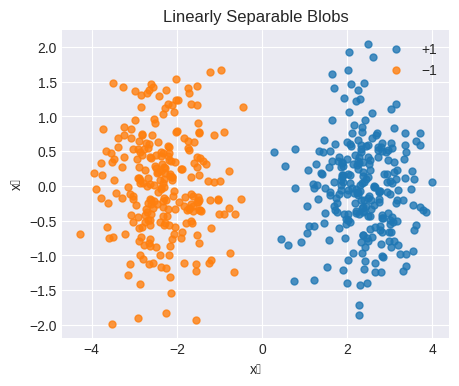

In [46]:
def plot_data(X: np.ndarray, y: np.ndarray, ax=None, title: str='Data'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(X[y==1, 0], X[y==1, 1], c='tab:blue', label='+1', s=25, alpha=0.8)
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c='tab:orange', label='−1', s=25, alpha=0.8)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.set_title(title)
    ax.legend(loc='best')
    return ax

_ = plot_data(X, y, title='Linearly Separable Blobs')
plt.show()


## 2) Perceptron Learning Algorithm (PLA)
**Update rule**: For each sample `(x_i, y_i)`, if it is misclassified (`y_i * w^T x_i ≤ 0`), update

$$\mathbf{w} \leftarrow \mathbf{w} + y_i \mathbf{x}_i$$

This exactly matches the "add/subtract features to weights when wrong" description (with an implicit learning rate of 1). Training repeats through epochs until there are no mistakes or a maximum number of epochs is reached.


In [51]:
def perceptron_train(Xb: np.ndarray, y: np.ndarray, max_epochs: int = 1000, shuffle: bool = True):
    n, d = Xb.shape
    w = np.zeros(d)
    mistakes_per_epoch = []
    updates = 0
    start = time.time()
    for epoch in range(max_epochs):
        idx = np.arange(n)
        if shuffle:
            np.random.shuffle(idx)
        mistakes = 0
        for i in idx:
            if y[i] * (Xb[i] @ w) <= 0:
                w = w + y[i] * Xb[i]
                mistakes += 1
                updates += 1
        mistakes_per_epoch.append(mistakes)
        if mistakes == 0:
            break
    elapsed = time.time() - start
    return w, {"mistakes_per_epoch": mistakes_per_epoch, "updates": updates, "epochs": len(mistakes_per_epoch), "time_sec": elapsed}

def predict_sign(Xb: np.ndarray, w: np.ndarray) -> np.ndarray:
    return np.sign(Xb @ w)

def accuracy(Xb: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    yhat = predict_sign(Xb, w)
    return (yhat == y).mean()

w_pla, stats_pla = perceptron_train(Xb, y, max_epochs=1000, shuffle=True)
acc_pla = accuracy(Xb, y, w_pla)
stats_pla, acc_pla


({'mistakes_per_epoch': [2, 0],
  'updates': 2,
  'epochs': 2,
  'time_sec': 0.0025250911712646484},
 np.float64(1.0))

## 3) Batch Gradient Descent on the Perceptron Loss
We optimize the (non-smooth) **perceptron loss** using batch gradient descent with a subgradient step. Each epoch:

1. Identify the misclassified set `ℓ = { i : y_i (w^T x_i) ≤ 0 }`.
2. Compute the batch subgradient `g = -
abla L = \sum_{i \in ℓ} y_i x_i`.
3. Update weights: `w ← w + lpha * g`.

We stop early if there are no misclassifications.


In [52]:
def gd_perceptron_train(Xb: np.ndarray, y: np.ndarray, alpha: float = 0.1, max_epochs: int = 1000):
    n, d = Xb.shape
    w = np.zeros(d)
    mistakes_per_epoch = []
    start = time.time()
    for epoch in range(max_epochs):
        margins = y * (Xb @ w)
        mis_idx = np.where(margins <= 0)[0]
        mistakes = len(mis_idx)
        mistakes_per_epoch.append(mistakes)
        if mistakes == 0:
            break
        # Batch subgradient: sum of y_i x_i over misclassified
        g = (y[mis_idx][:, None] * Xb[mis_idx]).sum(axis=0)
        w = w + alpha * g
    elapsed = time.time() - start
    return w, {"mistakes_per_epoch": mistakes_per_epoch, "epochs": len(mistakes_per_epoch), "time_sec": elapsed, "alpha": alpha}

w_gd, stats_gd = gd_perceptron_train(Xb, y, alpha=0.05, max_epochs=1000)
acc_gd = accuracy(Xb, y, w_gd)
stats_gd, acc_gd


({'mistakes_per_epoch': [500, 0],
  'epochs': 2,
  'time_sec': 0.0010669231414794922,
  'alpha': 0.05},
 np.float64(1.0))

## 4) Visualize decision boundaries
We overlay each model's separating hyperplane on the data.


/tmp/ipython-input-2968500324.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2968500324.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


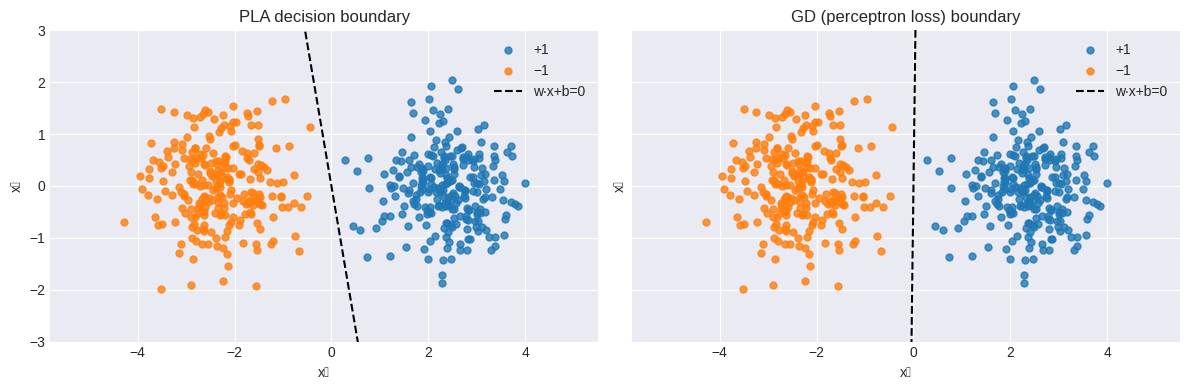

In [49]:
def plot_decision_boundary(X: np.ndarray, y: np.ndarray, w: np.ndarray, ax=None, title: str='Decision boundary'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))
    plot_data(X, y, ax=ax, title=title)
    # Extract linear boundary from w (for x in R^2; w = [w1, w2, b])
    w1, w2, b = w
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    xs = np.linspace(x_min, x_max, 200)
    if abs(w2) < 1e-8:
        # Vertical line
        x_vert = -b / (w1 + 1e-12)
        ax.axvline(x_vert, color='k', linestyle='--', label='w·x+b=0')
    else:
        ys = -(w1*xs + b) / (w2 + 1e-12)
        ax.plot(xs, ys, 'k--', label='w·x+b=0')
    ax.legend()
    return ax

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_decision_boundary(X, y, w_pla, ax=axes[0], title='PLA decision boundary')
plot_decision_boundary(X, y, w_gd,  ax=axes[1], title='GD (perceptron loss) boundary')
plt.ylim((-3,3))
plt.tight_layout()
plt.show()


## 6) Discussion
- On linearly separable data, the classic PLA is guaranteed to converge in a finite number of updates (Perceptron Convergence Theorem). In practice it often reaches zero training error quickly.
- Batch gradient descent on the perceptron loss also converges to a separating hyperplane when the data are separable, but its speed depends on the learning rate `α`. Too small `α` leads to slow progress; too large can oscillate.
- In this example, PLA typically needs *fewer* epochs but makes more *per-sample* updates; GD performs one batch step per epoch and can be more cache-friendly. Actual wall-clock time can vary by implementation and hardware.
- Both methods find a valid separator; their exact boundaries can differ because there are infinitely many separating hyperplanes for separable data.

**Try:**
- Change the data difficulty (`mean_offset`, `std`).
- Cap `max_epochs`, alter shuffling, or add a learning rate to PLA (e.g., `η<1`).
- Compare with logistic regression (smooth loss) or SVM (hinge loss with margin).


### Appendix: Utility to inspect parameters


In [53]:
print('PLA weights:', w_pla)
print('GD weights :', w_gd)


PLA weights: [ 2.7419329  -0.89009126  0.        ]
GD weights : [58.47082434 -0.78519181  0.        ]


In [54]:
print('PLA time:', stats_pla['time_sec'])
print('GD time :', stats_gd['time_sec'])

PLA time: 0.0025250911712646484
GD time : 0.0010669231414794922
